# 3-RRR Spherical Parallel Mechanism - Kinematics

**Author:** Chawin Ophaswongse  
**Date:** January 2026  
**Purpose:** Derivation and verification of SPM kinematic models

---

This notebook uses SymPy for symbolic computation to:
1. Derive inverse/forward kinematics equations
2. Derive Velocity Jacobian
3. Verify the C++ implementation formulas
4. Visualize mechanism configurations
5. Generate test cases with known solutions

## 1. Setup and Imports

In [79]:
# symbolic mathematics
import sympy as sp
from sympy import symbols, cos, sin, Matrix, sqrt, simplify, trigsimp
from sympy import pi, atan2, acos, asin
from sympy.vector import CoordSys3D

# numerical mathematics
import numpy as np

# import transformation calculations
from scipy.spatial.transform import Rotation as R

# plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image

# Enable pretty printing
sp.init_printing(use_unicode=True)

print("SymPy version:", sp.__version__)
print("NumPy version:", np.__version__)

SymPy version: 1.14.0
NumPy version: 1.24.2


## 2. Define Symbolic Variables

### Basic Architecture Parameters for Platform joint positions
- $\eta_{i1}, \eta_{i2} = 2(i-1)\pi/3, i = 1,2,3$ ($120^\circ$ increment): Rotation around base and moving platform z-axis , respectively
- $\gamma_{i1}$, $\gamma_{i2}$: Rotation around current base and moving platform x-axis, respectively
- Rotational Sequence $R_z(\eta_{i})R_x(\gamma_{i})$

### Architecture Parameters of FK
- $\alpha_{i1}$: Proximal link angle (angle from input axis to intermediate joint)
- $\alpha_{i2}$: Distal link angle (angle from intermediate joint to output)
- $\beta_{i1}$: Base joint orientation angles
- $\beta_{i2}$: Moving platform orientation angles

### Joint Variables
- $\theta_i$: Input joint angles (actuated)

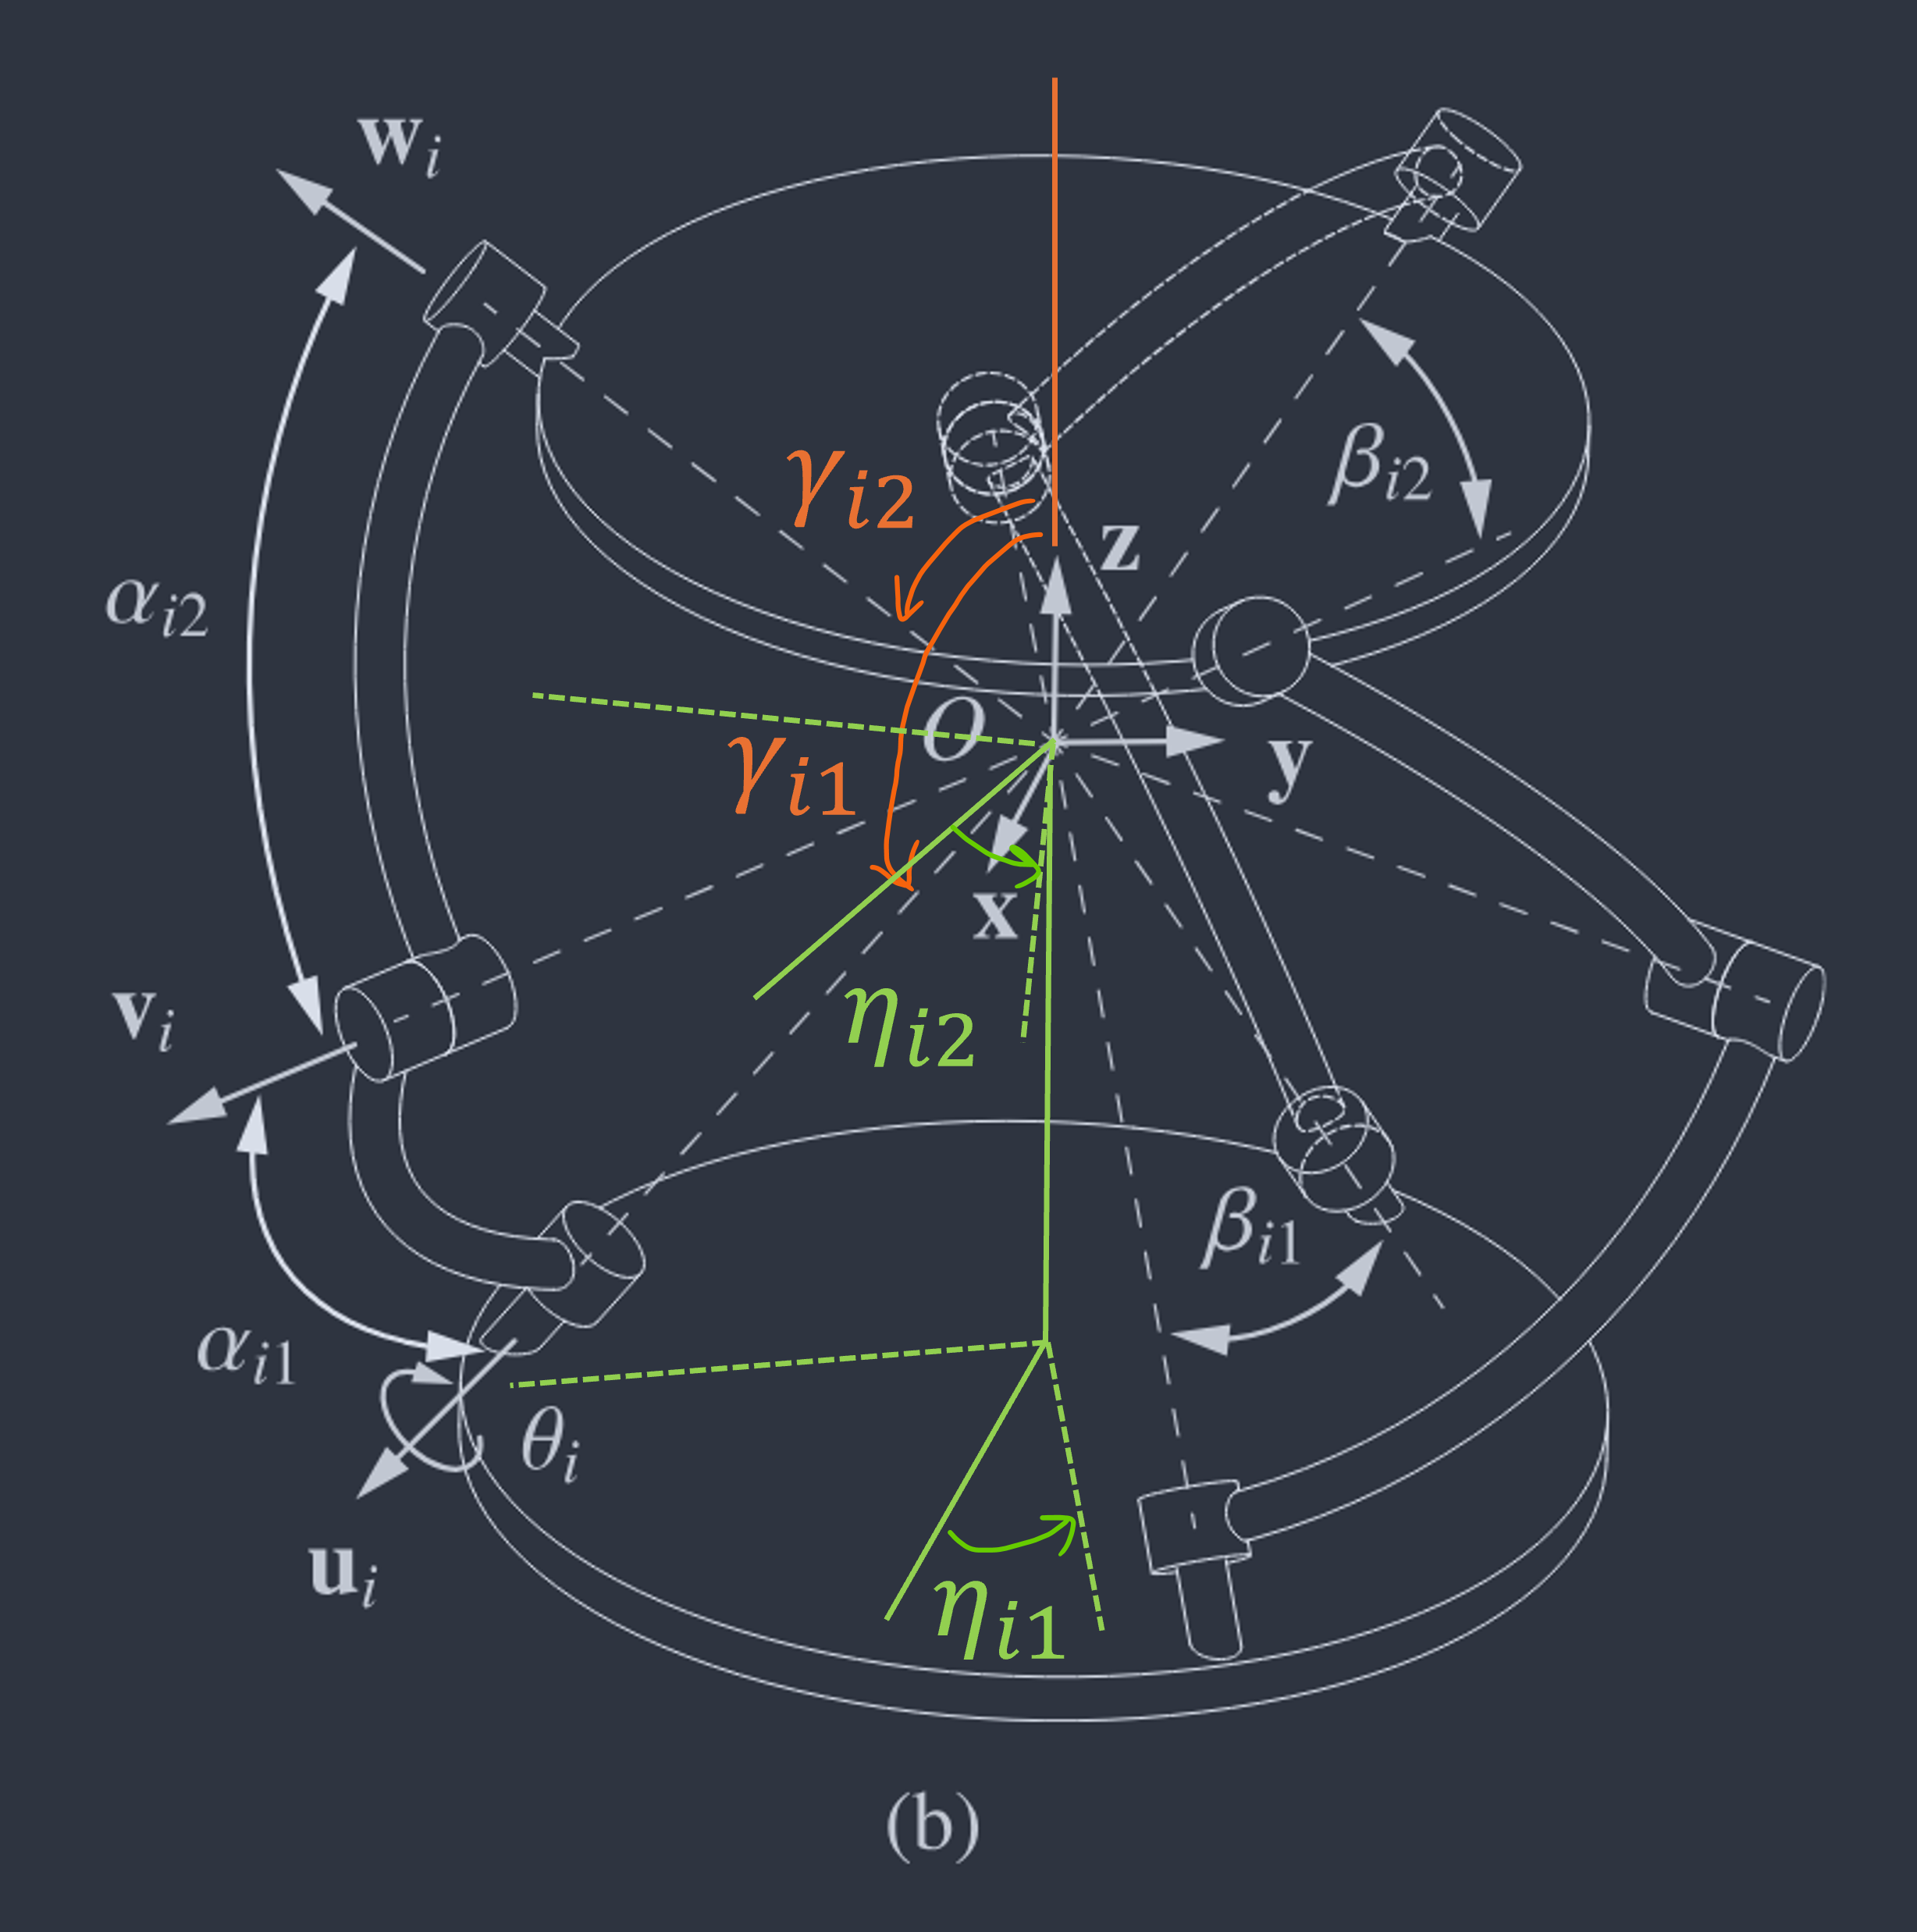

In [80]:
Image(filename='3RRR_spm_kinematic_diagram_annotated.png')

In [81]:
# Platform parameters (symbolic)
# Base platform
eta_11, eta_21, eta_31 = symbols('eta_11 eta_21 eta_31', real=True)
gamma_11, gamma_21, gamma_31 = symbols('gamma_11 gamma_21 gamma_31', real=True)

# Moving platform
eta_12, eta_22, eta_32 = symbols('eta_12 eta_22 eta_32', real=True)
gamma_12, gamma_22, gamma_32 = symbols('gamma_12 gamma_22 gamma_32', real=True)

# Architecture parameters (symbolic)
alpha_11, alpha_12, alpha_13 = symbols('alpha_11 alpha_12 alpha_13', real=True)
alpha_21, alpha_22, alpha_23 = symbols('alpha_21 alpha_22 alpha_23', real=True)
beta_11, beta_12, beta_13 = symbols('beta_11 beta_12 beta_13', real=True)
beta_21, beta_22, beta_23 = symbols('beta_21 beta_22 beta_23', real=True)

# Joint angles (input variables)
theta_1, theta_2, theta_3 = symbols('theta_1 theta_2 theta_3', real=True)

# Intermediate variables
epsilon_1, epsilon_2, epsilon_3 = symbols('epsilon_1 epsilon_2 epsilon_3', real=True)

# Group for convenience
theta = [theta_1, theta_2, theta_3]
alpha_i1 = [alpha_11, alpha_12, alpha_13]
alpha_i2 = [alpha_21, alpha_22, alpha_23]
beta_i1 = [beta_11, beta_12, beta_13]
beta_i2 = [beta_21, beta_22, beta_23]

# define rotation matrices in terms of R components
r11, r12, r13 = symbols('r11 r12 r13', real=True)
r21, r22, r23 = symbols('r21 r22 r23', real=True)
r31, r32, r33 = symbols('r31 r32 r33', real=True)
R_d = Matrix([[r11, r12, r13],
              [r21, r22, r23],
              [r31, r32, r33]])

wx, wy, wz = symbols('wx wy wz', real=True)
a1, a2, a3 = symbols('a1 a2 a3', real=True)
b1, b2, b3 = symbols('b1 b2 b3', real=True)
c1, c2, c3 = symbols('c1 c2 c3', real=True)

print("Joint angles:", theta)
print("Proximal link angles:", alpha_i1)
print("Desired Rotation Matrix R_d:", R_d)

Joint angles: [theta_1, theta_2, theta_3]
Proximal link angles: [alpha_11, alpha_12, alpha_13]
Desired Rotation Matrix R_d: Matrix([[r11, r12, r13], [r21, r22, r23], [r31, r32, r33]])


## Example of Class I: Agile Eye Configuration

For the Agile Eye (Class I with all angles = 90°):
- $\alpha_{i1} = \alpha_{i2} = \pi/2$ for all limbs
- $\beta_{i1}$ = base joint orientations (typically 0°, 120°, 240°)
- $\beta_{i2} = \pi/2$ (orthogonal moving platform)

## 3. Rotation Matrices

Define basic rotation matrices for spherical kinematics.

In [82]:
def Rx(angle):
    """Rotation matrix about X-axis"""
    return Matrix([
        [1, 0, 0],
        [0, cos(angle), -sin(angle)],
        [0, sin(angle), cos(angle)]
    ])

def Ry(angle):
    """Rotation matrix about Y-axis"""
    return Matrix([
        [cos(angle), 0, sin(angle)],
        [0, 1, 0],
        [-sin(angle), 0, cos(angle)]
    ])

def Rz(angle):
    """Rotation matrix about Z-axis"""
    return Matrix([
        [cos(angle), -sin(angle), 0],
        [sin(angle), cos(angle), 0],
        [0, 0, 1]
    ])

# numerical version
def Rx_num(angle):
    """Numerical rotation matrix about X-axis"""
    return np.array([
        [1, 0, 0],
        [0, np.cos(angle), -np.sin(angle)],
        [0, np.sin(angle), np.cos(angle)]
    ])

def Ry_num(angle):
    """Numerical rotation matrix about Y-axis"""
    return np.array([
        [np.cos(angle), 0, np.sin(angle)],
        [0, 1, 0],
        [-np.sin(angle), 0, np.cos(angle)]
    ])  

def Rz_num(angle):
    """Numerical rotation matrix about Z-axis"""
    return np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1]
    ])

# Display Rz as example
print("Rz(theta):")
Rz(theta_1)

Rz(theta):


⎡cos(θ₁)  -sin(θ₁)  0⎤
⎢                    ⎥
⎢sin(θ₁)  cos(θ₁)   0⎥
⎢                    ⎥
⎣   0        0      1⎦

## 4. Rodrigues' Rotation Formula

For rotating a vector $\mathbf{v}$ about axis $\mathbf{k}$ by angle $\theta$:

$$\mathbf{v}_{rot} = \mathbf{v} \cos\theta + (\mathbf{k} \times \mathbf{v}) \sin\theta + \mathbf{k}(\mathbf{k} \cdot \mathbf{v})(1 - \cos\theta)$$

In [83]:
def rodrigues_rotation(v, k, angle):
    """
    Rotate vector v about axis k by angle using Rodrigues' formula.
    
    Parameters:
    - v: 3x1 vector to rotate
    - k: 3x1 unit axis of rotation
    - angle: rotation angle
    
    Returns:
    - Rotated vector
    """
    v = Matrix(v)
    k = Matrix(k)
    
    # Cross product k x v
    k_cross_v = Matrix([
        k[1]*v[2] - k[2]*v[1],
        k[2]*v[0] - k[0]*v[2],
        k[0]*v[1] - k[1]*v[0]
    ])
    
    # Dot product k . v
    k_dot_v = k[0]*v[0] + k[1]*v[1] + k[2]*v[2]
    
    # Rodrigues' formula
    v_rot = v * cos(angle) + k_cross_v * sin(angle) + k * k_dot_v * (1 - cos(angle))
    
    return simplify(v_rot)

# Test: rotate [1, 0, 0] about z-axis by 90 degrees should give [0, 1, 0]
test_result = rodrigues_rotation([1, 0, 0], [0, 0, 1], pi/2)
print("Rotate [1,0,0] about z by 90°:")
print(test_result)


# numarical version of rodrigues_rotation
def rodrigues_rotation_num(v, k, angle):
    """
    Numerical version: Rotate vector v about axis k by angle using Rodrigues' formula.
    
    Parameters:
    - v: 3x1 vector to rotate (numpy array)
    - k: 3x1 unit axis of rotation (numpy array)
    - angle: rotation angle (float)
    
    Returns:
    - Rotated vector (numpy array)
    """
    v = np.array(v)
    k = np.array(k)
    
    k_cross_v = np.cross(k, v)
    k_dot_v = np.dot(k, v)
    
    v_rot = v * np.cos(angle) + k_cross_v * np.sin(angle) + k * k_dot_v * (1 - np.cos(angle))
    
    return v_rot

# test numerical version
test_result_num = rodrigues_rotation_num([1, 0, 0], [0, 0, 1], np.pi/2)
print("Numerical Rotate [1,0,0] about z by 90°:")
print(test_result_num)

Rotate [1,0,0] about z by 90°:
Matrix([[0], [1], [0]])
Numerical Rotate [1,0,0] about z by 90°:
[6.123234e-17 1.000000e+00 0.000000e+00]


## 5. Intermediate Joint Axis (v-vector) Computation

**This is the critical formula for verifying IK**

The v-vector represents the direction of the intermediate joint axis after rotating the proximal link by $\theta_i$.

In [84]:
# compute unit vectors u_i, v_i, w_i for leg 1
Ru1 = Rz(eta_11) * Rx(gamma_11)
u1 = Ru1 * Matrix([0, 0, 1])

Rv1 = Ru1 * Rz(theta_1) * Rx(alpha_11) 
v1 = trigsimp(Rv1 * Matrix([0, 0, 1]))

Rw1 = Rv1 * Rz(epsilon_1) * Rx(alpha_12)
w1 = Rw1 * Matrix([0, 0, 1])

print("Unit vector u_i and v_i along z axis for platform joint position:")
trigsimp(u1), v1, w1

Unit vector u_i and v_i along z axis for platform joint position:


⎛⎡sin(η₁₁)⋅sin(γ₁₁) ⎤  ⎡ (sin(η₁₁)⋅cos(γ₁₁)⋅cos(θ₁) + sin(θ₁)⋅cos(η₁₁))⋅sin(α₁ ↪
⎜⎢                  ⎥  ⎢                                                       ↪
⎜⎢-sin(γ₁₁)⋅cos(η₁₁)⎥, ⎢-(-sin(η₁₁)⋅sin(θ₁) + cos(η₁₁)⋅cos(γ₁₁)⋅cos(θ₁))⋅sin(α ↪
⎜⎢                  ⎥  ⎢                                                       ↪
⎝⎣     cos(γ₁₁)     ⎦  ⎣                    -sin(α₁₁)⋅sin(γ₁₁)⋅cos(θ₁) + cos(α ↪

↪ ₁) + sin(η₁₁)⋅sin(γ₁₁)⋅cos(α₁₁) ⎤  ⎡-(((-sin(η₁₁)⋅cos(γ₁₁)⋅cos(θ₁) - sin(θ₁) ↪
↪                                 ⎥  ⎢                                         ↪
↪ ₁₁) - sin(γ₁₁)⋅cos(α₁₁)⋅cos(η₁₁)⎥, ⎢-(((-sin(η₁₁)⋅sin(θ₁) + cos(η₁₁)⋅cos(γ₁₁ ↪
↪                                 ⎥  ⎢                                         ↪
↪ ₁₁)⋅cos(γ₁₁)                    ⎦  ⎣                                         ↪

↪ ⋅cos(η₁₁))⋅cos(α₁₁) + sin(α₁₁)⋅sin(η₁₁)⋅sin(γ₁₁))⋅cos(ε₁) - (-sin(η₁₁)⋅sin(θ ↪
↪                                                                              ↪
↪ )⋅cos(θ₁))⋅cos(α₁₁) - si

In [85]:
# double check dot product u1 . v1
u1_dot_v1 = trigsimp(u1.dot(v1))
# expecting cos(alpha_11)
u1_dot_v1

In [86]:
# double check dot product v1 . w1
v1_dot_w1 = trigsimp(v1.dot(w1))
# expecting cos(alpha_12)
v1_dot_w1

In [87]:
# Symbolically Compute w_i in terms of R_d
w_10 = Rz(eta_12) * Rx(gamma_12) * Matrix([0, 0, 1])
# w_1 = R_d * Rz(eta_12) * Rx(gamma_12) * Matrix([0, 0, 1])
# w_10, w_1
w_10

⎡sin(η₁₂)⋅sin(γ₁₂) ⎤
⎢                  ⎥
⎢-sin(γ₁₂)⋅cos(η₁₂)⎥
⎢                  ⎥
⎣     cos(γ₁₂)     ⎦

In [88]:
v_1 = Matrix([a1*cos(theta_1) + b1*sin(theta_1) + c1,
              a2*cos(theta_1) + b2*sin(theta_1) + c2,
              a3*cos(theta_1) + c3])
w_1 = Matrix([wx, wy, wz])
v_1_dot_w_1 = trigsimp(v_1.dot(w_1))
v_1_dot_w_1

# print(v_1_dot_w_1)

---
## 6. IK Constraint: Trigonometric Equation Solver (Per Leg)

For each leg $(i \in \{1,2,3\})$, the inverse kinematics constraint

$$
\mathbf{v}_i \cdot \mathbf{w}_i = \cos(\alpha_{i2})
$$

leads to a trigonometric equation of the form

$$
A_i \cos\theta_i + B_i \sin\theta_i = C_i
$$

where the coefficients $(A_i, B_i, C_i)$ are computed independently for each leg.

---

# Trigonometric Precomputation

Define the following trigonometric quantities (numerical constants)

$$
c_{\eta_{i1}} = \cos(\eta_{i1}), \qquad s_{\eta_{i1}} = \sin(\eta_{i1})
$$

$$
c_{\gamma_{i1}} = \cos(\gamma_{i1}), \qquad s_{\gamma_{i1}} = \sin(\gamma_{i1})
$$

$$
c_{\eta_{i2}} = \cos(\eta_{i2}), \qquad s_{\eta_{i2}} = \sin(\eta_{i2})
$$

$$
c_{\gamma_{i2}} = \cos(\gamma_{i2}), \qquad s_{\gamma_{i2}} = \sin(\gamma_{i2})
$$

$$
c_{\alpha_{i1}} = \cos(\alpha_{i1}), \qquad s_{\alpha_{i1}} = \sin(\alpha_{i1})
$$

---

# Coefficients of the Vector $(v_i)$

The vector \(v_i\) can be written in the form

$$
v_i =
\begin{bmatrix}
a_{1i}\cos\theta_i + b_{1i}\sin\theta_i + c_{1i} \\
a_{2i}\cos\theta_i + b_{2i}\sin\theta_i + c_{2i} \\
a_{3i}\cos\theta_i + b_{3i}\sin\theta_i + c_{3i}
\end{bmatrix}
$$

where

$$
a_{1i} = s_{\eta_{i1}} c_{\gamma_{i1}} s_{\alpha_{i1}}
$$

$$
b_{1i} = c_{\eta_{i1}} s_{\alpha_{i1}}
$$

$$
c_{1i} = s_{\eta_{i1}} s_{\gamma_{i1}} c_{\alpha_{i1}}
$$

---

$$
a_{2i} = -c_{\eta_{i1}} c_{\gamma_{i1}} s_{\alpha_{i1}}
$$

$$
b_{2i} = s_{\eta_{i1}} s_{\alpha_{i1}}
$$

$$
c_{2i} = -c_{\eta_{i1}} s_{\gamma_{i1}} c_{\alpha_{i1}}
$$

---

$$
a_{3i} = -s_{\gamma_{i1}} s_{\alpha_{i1}}
$$

$$
b_{3i} = 0
$$

$$
c_{3i} = c_{\gamma_{i1}} c_{\alpha_{i1}}
$$

---

# Platform Vector $(w_i)$

The platform attachment vector is

$$
w_{i0} =
\begin{bmatrix}
s_{\eta_{i2}} s_{\gamma_{i2}} \\
- c_{\eta_{i2}} s_{\gamma_{i2}} \\
c_{\gamma_{i2}}
\end{bmatrix}
$$

and after applying the desired rotation

$$
w_i = R_{des} w_{i0}
$$

---

# Coefficients of the Trigonometric Equation

Substituting \(v_i\) into

$$
v_i \cdot w_i = \cos(\alpha_{i2})
$$

gives

$$
A_i \cos\theta_i + B_i \sin\theta_i = C_i
$$

with

$$
A_i =
w_{ix} a_{1i}
+
w_{iy} a_{2i}
+
w_{iz} a_{3i}
$$

$$
B_i =
w_{ix} b_{1i}
+
w_{iy} b_{2i}
+
w_{iz} b_{3i}
$$

$$
C_i =
\cos(\alpha_{i2})
-
\left(
w_{ix} c_{1i}
+
w_{iy} c_{2i}
+
w_{iz} c_{3i}
\right)
$$

---

# Analytical Solution Using Tangent Half-Angle

The equation

$$
A_i\cos\theta_i + B_i\sin\theta_i = C_i
$$

has a closed-form analytical solution.

Let

$$
t = \tan\left(\frac{\theta_i}{2}\right)
$$

Then

$$
\cos\theta_i = \frac{1 - t^2}{1 + t^2}
$$

$$
\sin\theta_i = \frac{2t}{1 + t^2}
$$

Substituting gives

$$
(A_i + C_i)t^2 - 2B_i t + (C_i - A_i) = 0
$$

---

# Quadratic Solution

$$
t =
\frac{B_i \pm \sqrt{A_i^2 + B_i^2 - C_i^2}}{A_i + C_i}
$$

<!-- ---

# Final Joint Angle

$$
\boxed{
\theta_i =
2 \arctan
\left(
\frac{B_i \pm \sqrt{A_i^2 + B_i^2 - C_i^2}}
{A_i + C_i}
\right)
}
$$ -->

---

# Final Joint Angle Numerically Stable Evaluation

A numerically stable computation using the $\arctan2(y,x)$ function with $\cos\theta_i = \frac{1 - t^2}{1 + t^2}$
and $\sin\theta_i = \frac{2t}{1 + t^2}$ is 

$$
\boxed{
\theta_i =
\arctan2(2t,\,1 - t^2)
}
$$

---

# Existence Condition

Real solutions exist only if

$$
A_i^2 + B_i^2 \ge C_i^2
$$

which geometrically means that the projection magnitude

$$
\sqrt{A_i^2 + B_i^2}
$$

must be at least $( |C_i| )$.

In [89]:
from sympy import atan, tan, solve, Eq

def solve_trig_equation_symbolic(A, B, C):
    """
    Solve A*cos(θ) + B*sin(θ) = C symbolically.
    Uses tangent half-angle substitution: t = tan(θ/2)
    
    Returns: List of solutions for θ
    """
    t = symbols('t', real=True)
    
    # Quadratic equation: (A + C)*t² - 2B*t + (C - A) = 0
    quadratic_eq = (A + C)*t**2 - 2*B*t + (C - A)
    
    # Solve for t
    t_solutions = solve(quadratic_eq, t)
    
    # Convert to θ = 2*atan(t)
    theta_solutions = [simplify(2 * atan(t_sol)) for t_sol in t_solutions]
    
    return theta_solutions

# Display the general solution
A_sym, B_sym, C_sym = symbols('A B C', real=True)
print("General solution for A·cos(θ) + B·sin(θ) = C:")
print("=" * 50)
solutions = solve_trig_equation_symbolic(A_sym, B_sym, C_sym)
for i, sol in enumerate(solutions):
    print(f"\nθ_{i+1} = {sol}")

General solution for A·cos(θ) + B·sin(θ) = C:

θ_1 = 2*atan((B - sqrt(A**2 + B**2 - C**2))/(A + C))

θ_2 = 2*atan((B + sqrt(A**2 + B**2 - C**2))/(A + C))


In [90]:
def solve_trig_equation_numerical(A, B, C):
    """
    Solve A*cos(θ) + B*sin(θ) = C numerically.
    
    Returns: List of solutions for θ (radians), or empty if no solution exists
    """
    # Check existence condition: A² + B² ≥ C²
    discriminant = A**2 + B**2 - C**2
    
    if discriminant < 0:
        return []  # No solution
    
    # Handle special case: A + C ≈ 0
    if np.abs(A + C) < 1e-10:
        if np.abs(B) < 1e-10:
            return []  # Degenerate
        t = (C - A) / (2 * B)
        return [2 * np.arctan(t)]
    
    # Quadratic solution: t = [B ± √(A² + B² - C²)] / (A + C)
    sqrt_disc = np.sqrt(discriminant)
    t1 = (B + sqrt_disc) / (A + C) 
    t2 = (B - sqrt_disc) / (A + C) 

    sin_theta1 = 2 * t1 / (1 + t1**2)
    cos_theta1 = (1 - t1**2) / (1 + t1**2)

    sin_theta2 = 2 * t2 / (1 + t2**2)
    cos_theta2 = (1 - t2**2) / (1 + t2**2)

    # check sin² + cos² ≈ 1 for both solutions
    if not (np.isclose(sin_theta1**2 + cos_theta1**2, 1, atol=1e-10) and np.isclose(sin_theta2**2 + cos_theta2**2, 1, atol=1e-10)):
        print("Warning: Numerical instability detected in trigonometric solution. Sin(t)² + Cos(t)² not close to 1.")
        return []  # Numerical instability  
    
    theta1 = np.arctan2(sin_theta1, cos_theta1)
    theta2 = np.arctan2(sin_theta2, cos_theta2)
    
    # Return unique solutions
    if np.abs(theta1 - theta2) < 1e-10:
        return [theta1]
    return [theta1, theta2]

# Test the solver
print("=" * 50)
print("IK Trigonometric Solver - Test Cases")
print("=" * 50)

test_cases = [
    (1, 0, 0.5, "cos(θ) = 0.5 → θ = ±60°"),
    (0, 1, 0.5, "sin(θ) = 0.5 → θ = 30°, 150°"),
    (1, 1, 1, "cos(θ) + sin(θ) = 1"),
    (1, 1, np.sqrt(2), "cos(θ) + sin(θ) = √2 (boundary)"),
    (1, 0, 2, "cos(θ) = 2 (no solution)"),
]

for A, B, C, desc in test_cases:
    solutions = solve_trig_equation_numerical(A, B, C)
    print(f"\n{desc}:")
    if solutions:
        for i, theta in enumerate(solutions):
            check = A * np.cos(theta) + B * np.sin(theta)
            print(f"  θ_{i+1} = {np.degrees(theta):8.2f}° | Verify: {check:.6f} ≈ {C}")
    else:
        print("  No solution exists")

IK Trigonometric Solver - Test Cases

cos(θ) = 0.5 → θ = ±60°:
  θ_1 =    60.00° | Verify: 0.500000 ≈ 0.5
  θ_2 =   -60.00° | Verify: 0.500000 ≈ 0.5

sin(θ) = 0.5 → θ = 30°, 150°:
  θ_1 =   150.00° | Verify: 0.500000 ≈ 0.5
  θ_2 =    30.00° | Verify: 0.500000 ≈ 0.5

cos(θ) + sin(θ) = 1:
  θ_1 =    90.00° | Verify: 1.000000 ≈ 1
  θ_2 =     0.00° | Verify: 1.000000 ≈ 1

cos(θ) + sin(θ) = √2 (boundary):
  No solution exists

cos(θ) = 2 (no solution):
  No solution exists


## 8. Numerical Verification

Convert symbolic expressions to numerical values for testing.

In [91]:
def u_vector_numerical_subs(eta_i1_val, gamma_i1_val):
    """
    Numerical computation of u-vector using direct substitution from symbolic derivation.
    
    u_i = Rz(eta) * Rx(gamma) * [0, 0, 1]
    
    Parameters:
        eta_i1_val: Z-axis rotation for joint position
        gamma_i1_val: X-axis tilt for joint position
    """
    c_eta = np.cos(eta_i1_val)
    s_eta = np.sin(eta_i1_val)
    c_gamma = np.cos(gamma_i1_val)
    s_gamma = np.sin(gamma_i1_val)
    
    # Direct substitution from symbolic: Rz(eta)*Rx(gamma)*[0,0,1]
    u_x = s_eta * s_gamma
    u_y = -c_eta * s_gamma
    u_z = c_gamma

    # verify normalization
    norm_u = np.sqrt(u_x**2 + u_y**2 + u_z**2)
    assert np.isclose(norm_u, 1.0), f"u-vector not normalized: |u|={norm_u}"
    
    return np.array([u_x, u_y, u_z])

def u_vector_numerical(eta_i1_val, gamma_i1_val):
    """
    Numerical computation of u-vector using rotational matrices.
    
    u_i = Rz(eta) * Rx(gamma) * [0, 0, 1]
    
    Parameters:
        eta_i1_val: Z-axis rotation for joint position
        gamma_i1_val: X-axis tilt for joint position
    """
    Ru = Rz_num(eta_i1_val) @ Rx_num(gamma_i1_val)
    u = Ru @ np.array([0, 0, 1])
    
    # verify normalization
    norm_u = np.sqrt(u[0]**2 + u[1]**2 + u[2]**2)
    assert np.isclose(norm_u, 1.0), f"u-vector not normalized: |u|={norm_u}"
    
    return u, Ru

def v_vector_numerical_subs(theta_i_val, eta_i1_val, gamma_i1_val, alpha_i1_val):
    """
    Numerical computation of v-vector using direct substitution from symbolic derivation.
    
    v_i = Rz(eta) * Rx(gamma) * Rz(theta) * Rx(alpha) * [0, 0, 1]
    
    Parameters:
        theta_i_val: Joint angle
        eta_i1_val: Z-axis rotation for joint position
        gamma_i1_val: X-axis tilt for joint position
        alpha_i1_val: Link angle (proximal)
    """
    c_theta = np.cos(theta_i_val)
    s_theta = np.sin(theta_i_val)
    c_eta = np.cos(eta_i1_val)
    s_eta = np.sin(eta_i1_val)
    c_gamma = np.cos(gamma_i1_val)
    s_gamma = np.sin(gamma_i1_val)
    c_alpha = np.cos(alpha_i1_val)
    s_alpha = np.sin(alpha_i1_val)
    
    # Direct substitution from symbolic: Rz(eta)*Rx(gamma)*Rz(theta)*Rx(alpha)*[0,0,1]
    v_x = (s_eta * c_gamma * c_theta + s_theta * c_eta) * s_alpha + s_eta * s_gamma * c_alpha
    v_y = -(-s_eta * s_theta + c_eta * c_gamma * c_theta) * s_alpha - s_gamma * c_alpha * c_eta
    v_z = -s_alpha * s_gamma * c_theta + c_alpha * c_gamma

    # verify normalization
    norm_v = np.sqrt(v_x**2 + v_y**2 + v_z**2)
    assert np.isclose(norm_v, 1.0), f"v-vector not normalized: |v|={norm_v}"
    
    return np.array([v_x, v_y, v_z])

def v_vector_numerical(theta_i_val, eta_i1_val, gamma_i1_val, alpha_i1_val):
    """
    Numerical computation of v-vector using rotational matrices.
    """
    Ru = Rz_num(eta_i1_val) @ Rx_num(gamma_i1_val)
    
    Rv = Ru @ Rz_num(theta_i_val) @ Rx_num(alpha_i1_val)
    v = Rv @ np.array([0, 0, 1])
    
    # verify normalization
    norm_v = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
    assert np.isclose(norm_v, 1.0), f"v-vector not normalized: |v|={norm_v}"
    
    return v, Rv
  
# Test cases
print("=== Numerical v-vector tests ===")
test_cases = [
    (0, 0, 0, np.pi/6),           # theta=0, eta=0, gamma=0°, alpha=60°, beta=90°
    (np.pi/6, 0, 0, np.pi/4),     # theta=30°, eta=60, gamma=0°, alpha=45°, beta=45°
    (0, np.pi/2, 2*np.pi/3, 0)    # theta=90, eta=120°, gamma=120°, alpha=0°, beta=0°
]

for theta_i_val, eta_i1_val, gamma_i1_val, alpha_i1_val in test_cases:
    u = u_vector_numerical(eta_i1_val, gamma_i1_val)[0];''
    u_sub = u_vector_numerical_subs(eta_i1_val, gamma_i1_val)
    v = v_vector_numerical(theta_i_val, eta_i1_val, gamma_i1_val, alpha_i1_val)[0]
    v_sub = v_vector_numerical_subs(theta_i_val, eta_i1_val, gamma_i1_val, alpha_i1_val)

    print(f"theta_i={np.degrees(theta_i_val):6.1f}°, eta_i1={np.degrees(eta_i1_val):5.1f}°, gamma_i1={np.degrees(gamma_i1_val):5.1f}°, alpha_i1={np.degrees(alpha_i1_val):5.1f}°")
    print(f"  u = [{u[0]:8.4f}, {u[1]:8.4f}, {u[2]:8.4f}]")
    print(f"  u_sub = [{u_sub[0]:8.4f}, {u_sub[1]:8.4f}, {u_sub[2]:8.4f}]")
    assert np.allclose(u, u_sub), "u-vector mismatch between methods"
    print("  u-vectors match between methods.")
    # print verification of normalization of both u
    print("  Verification: |u| =", np.linalg.norm(u))
    print("  Verification: |u_sub| =", np.linalg.norm(u_sub))

    print(f"  v = [{v[0]:8.4f}, {v[1]:8.4f}, {v[2]:8.4f}]")
    print(f"  v_sub = [{v_sub[0]:8.4f}, {v_sub[1]:8.4f}, {v_sub[2]:8.4f}]")
    assert np.allclose(v, v_sub), "v-vector mismatch between methods"
    print("  v-vectors match between methods.")
    # print verification of normalization of both v
    print("  Verification: |v| =", np.linalg.norm(v))
    print("  Verification: |v_sub| =", np.linalg.norm(v_sub))
    print()

=== Numerical v-vector tests ===
theta_i=   0.0°, eta_i1=  0.0°, gamma_i1=  0.0°, alpha_i1= 30.0°
  u = [  0.0000,   0.0000,   1.0000]
  u_sub = [  0.0000,  -0.0000,   1.0000]
  u-vectors match between methods.
  Verification: |u| = 1.0
  Verification: |u_sub| = 1.0
  v = [  0.0000,  -0.5000,   0.8660]
  v_sub = [  0.0000,  -0.5000,   0.8660]
  v-vectors match between methods.
  Verification: |v| = 1.0
  Verification: |v_sub| = 1.0

theta_i=  30.0°, eta_i1=  0.0°, gamma_i1=  0.0°, alpha_i1= 45.0°
  u = [  0.0000,   0.0000,   1.0000]
  u_sub = [  0.0000,  -0.0000,   1.0000]
  u-vectors match between methods.
  Verification: |u| = 1.0
  Verification: |u_sub| = 1.0
  v = [  0.3536,  -0.6124,   0.7071]
  v_sub = [  0.3536,  -0.6124,   0.7071]
  v-vectors match between methods.
  Verification: |v| = 1.0
  Verification: |v_sub| = 1.0

theta_i=   0.0°, eta_i1= 90.0°, gamma_i1=120.0°, alpha_i1=  0.0°
  u = [  0.8660,  -0.0000,  -0.5000]
  u_sub = [  0.8660,  -0.0000,  -0.5000]
  u-vectors matc

# Jacobian Derivation for 3-RRR Manipulator

## Velocity Constraint

For each leg $i = 1,2,3$:

$$
\mathbf{v}_i \cdot \mathbf{w}_i = 0
$$

Taking time derivative:

$$
\dot{\mathbf{v}}_i \cdot \mathbf{w}_i
+
\mathbf{v}_i \cdot \dot{\mathbf{w}}_i
= 0
$$

---

## Angular Velocity Relations

Platform velocity contribution:

$$
\dot{\mathbf{v}}_i
=
\dot{\theta}_i
(\mathbf{u}_i \times \mathbf{v}_i)
$$

Relative angular velocity:

$$
\dot{\mathbf{w}}_i
=
\boldsymbol{\omega}
\times
\mathbf{w}_i
$$

Substitute into the constraint:

$$
\dot{\theta}_i
(\mathbf{u}_i \times \mathbf{v}_i)
\cdot
\mathbf{w}_i
+
\mathbf{v}_i
\cdot
(\boldsymbol{\omega} \times \mathbf{w}_i)
=
0
$$

---

## Scalar Triple Product Identity

Using:

$$
\mathbf{a} \cdot (\mathbf{b} \times \mathbf{c})
=
\mathbf{b} \cdot (\mathbf{c} \times \mathbf{a})
=
\mathbf{c} \cdot (\mathbf{a} \times \mathbf{b})
$$

Rewrite:

$$
\mathbf{v}_i \cdot (\boldsymbol{\omega} \times \mathbf{w}_i)
=
\boldsymbol{\omega} \cdot (\mathbf{w}_i \times \mathbf{v}_i)
$$

Thus:

$$
-\dot{\theta}_i
\,\mathbf{u}_i \cdot (\mathbf{w}_i \times \mathbf{v}_i)
+
(\mathbf{w}_i \times \mathbf{v}_i)^T
\boldsymbol{\omega}
=
0
$$

Rearranging:

$$
(\mathbf{w}_i \times \mathbf{v}_i)^T
\boldsymbol{\omega}
=
\mathbf{u}_i \cdot (\mathbf{w}_i \times \mathbf{v}_i)
\dot{\theta}_i
$$

---

# Matrix Form

Stacking $i=1,2,3$:

$$
\underbrace{
\begin{bmatrix}
(\mathbf{w}_1 \times \mathbf{v}_1)^T \\
(\mathbf{w}_2 \times \mathbf{v}_2)^T \\
(\mathbf{w}_3 \times \mathbf{v}_3)^T
\end{bmatrix}
}_{\mathbf{A}}
\boldsymbol{\omega}
=
\underbrace{
\begin{bmatrix}
\mathbf{u}_1 \cdot (\mathbf{w}_1 \times \mathbf{v}_1) & 0 & 0 \\
0 & \mathbf{u}_2 \cdot (\mathbf{w}_2 \times \mathbf{v}_2) & 0 \\
0 & 0 & \mathbf{u}_3 \cdot (\mathbf{w}_3 \times \mathbf{v}_3)
\end{bmatrix}
}_{\mathbf{B}}
\begin{bmatrix}
\dot{\theta}_1 \\
\dot{\theta}_2 \\
\dot{\theta}_3
\end{bmatrix}
$$

---

# Final Jacobian Form

$$
\mathbf{A}\boldsymbol{\omega}
=
\mathbf{B}\dot{\boldsymbol{\theta}}
$$

$$
\boldsymbol{\omega}
=
\mathbf{A}^{-1}\mathbf{B}\dot{\boldsymbol{\theta}}
$$

Thus,

$$
\mathbf{J}
=
\mathbf{A}^{-1}\mathbf{B}
$$

---

# Singularity Conditions

Platform singularity:

$$
\det(\mathbf{A}) = 0
$$

Leg singularity:

$$
\det(\mathbf{B}) = 0
$$



## Conditioning Index of the Jacobian

Given a Jacobian matrix $$J \in \mathbb{R}^{3 \times 3}$$, the conditioning index is defined as the reciprocal of the condition number:

$$
\zeta(J) = \kappa^{-1}(J) = \frac{1}{||J||||J^{-1}||}
$$

---

## Matrix Norm Used in the Implementation

The norm implemented in the code is:

$$
||J|| = \sqrt{\operatorname{trace}\left(J^\top \left(\frac{1}{3} I_3\right) J \right)}
$$

where $I_3$ is the $3 \times 3$ identity matrix.

---

## Simplified Form

Since

$$
\operatorname{trace}\left(J^\top \left(\frac{1}{3} I_3\right) J \right)

=

\frac{1}{3}\operatorname{trace}(J^\top J)
$$

and

$$
\operatorname{trace}(J^\top J) = |J|_F^2
$$

(where $|\cdot|_F$ is the Frobenius norm), we obtain:

$$
||J|| = \sqrt{\frac{1}{3}} |J|_F
$$

---

## Final Expression of the Conditioning Index

Therefore, the conditioning index used in the code is:

$$
\zeta(J)
=
\kappa^{-1}(J)
=

\frac{1}
{
\sqrt{\operatorname{trace}\left(J^T \left(\frac{1}{3} I_3\right) J \right)}
\sqrt{\operatorname{trace}\left(J^{-T} \left(\frac{1}{3} I_3\right) J^{-1} \right)}
}
$$

which is equivalent to:

$$
\kappa^{-1}(J)
=
\frac{1}{||J||  ||J^{-1}||}
$$

---

## Interpretation

* If $\kappa^{-1}(J) \approx 1$ → well-conditioned (near isotropic)
* If $\kappa^{-1}(J) \to 0$ → near singular
* At singularity, $||J^{-1}|| \to \infty$, so

$
\kappa^{-1}(J) \to 0
$

---


## 9. Visualization

3D plot of the mechanism configuration.# Visualization

In [92]:
import numpy as np
import matplotlib.pyplot as plt

def _plot_coordinate_frame(ax, R, origin=np.zeros(3), length=1.0, frame_label=None, **kwargs):
    """
    Plot a 3D coordinate frame given rotation matrix R and origin.
    """
    origin = np.asarray(origin).flatten()
    x_axis = R[:, 0] * length
    y_axis = R[:, 1] * length
    z_axis = R[:, 2] * length

    linewidth = 0.5
    ax.quiver(
        origin[0], origin[1], origin[2],
        x_axis[0], x_axis[1], x_axis[2],
        color='r', label=f'X-axis{f" ({frame_label})" if frame_label else ""}', linewidth=linewidth, **kwargs
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        y_axis[0], y_axis[1], y_axis[2],
        color='g', label=f'Y-axis{f" ({frame_label})" if frame_label else ""}', linewidth=linewidth, **kwargs
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        z_axis[0], z_axis[1], z_axis[2],
        color='b', label=f'Z-axis{f" ({frame_label})" if frame_label else ""}', linewidth=linewidth, **kwargs
    )

def _plot_single_quiver(ax, v, color='b', label=None, length=1.0, **kwargs):
    """
    Plot a single 3D quiver on an existing axis.
    """
    origin = np.zeros(3)
    v = np.asarray(v).flatten()

    ax.quiver(
        origin[0], origin[1], origin[2],
        v[0], v[1], v[2],
        length=length, normalize=True,
        color=color, label=label, **kwargs
    )

def plot_unit_vectors(ax, v, linestyle='-', name=None, length=0.5):
    """
    Plot a 3D unit vector or a list of unit vectors in the same figure.
    """
    # If v is a list/array of vectors (Nx3)
    v = np.asarray(v)
    if v.ndim == 1:
        v = v.reshape(1, -1)
    v = v / np.linalg.norm(v, axis=1, keepdims=True) * length

    if v.ndim == 2:
        colors = ['c', 'm', 'y', 'r', 'g', 'b']
        for i, vi in enumerate(v):
            _plot_single_quiver(
                ax, vi,
                color=colors[i % len(colors)],
                label=f"{name}{i+1}",
                linestyle=linestyle,
                length=length
            )
        # move legend outside the plot
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    else:
        _plot_single_quiver(ax, v, color='b', label=name, linestyle=linestyle, length=length)


def plot_spsm_transformation(ax, u_i, v_i, w_i, R_des):
    """
    Plot the SPM transformation including base frame, desired frame,
    and unit vectors u_i and w_i.
    """

    common_length = 0.1

    _plot_coordinate_frame(ax, np.eye(3), length=common_length, frame_label='Base')
    _plot_coordinate_frame(ax, R_des, length=common_length, linestyle='--', frame_label='MP') 

    # Example usage: plot the computed u_i and w_i vectors
    # print("\nPlotting u_i vectors...")
    # plot_unit_vectors(ax=ax, v=u_i, name='u_', linestyle='-', length=common_length)

    # print("\nPlotting v_i vectors...")
    # plot_unit_vectors(ax=ax, v=v_i, name='v_', linestyle='-.', length=common_length)

    # print("\nPlotting w_i vectors...")
    plot_unit_vectors(ax=ax, v=w_i, name='w_', linestyle='--', length=common_length)

    # plot lines between w_i vectors
    w_i_mp = common_length * np.asarray(w_i)
    w_i_mp = np.vstack([w_i_mp, w_i_mp[0]])  # close the loop for visualization
    ax.plot(w_i_mp[:, 0], w_i_mp[:, 1], w_i_mp[:, 2], color='k', linestyle='-')

    # Axis formatting
    bound = 0.125
    ax.set_xlim([-bound, bound])
    ax.set_ylim([-bound, bound])
    ax.set_zlim([-bound, bound])
    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


In [93]:
# plot 3D cylinder of joint
def plot_joint_cylinder(ax, tf_mat=np.eye(4), z_offset=0.0, radius=0.0125, height=0.025, color='cyan', alpha=1.0):
    # number of points around circumference and height
    N = 50
    if tf_mat.shape != (4, 4):
        if tf_mat.shape == (3, 3):
            tf_mat_full = np.eye(4)
            tf_mat_full[:3, :3] = tf_mat
            tf_mat = tf_mat_full
        elif tf_mat.shape == (3,):
            tf_mat_full = np.eye(4)
            tf_mat_full[:3, 2] = tf_mat
            # find axis of rotation from [0, 0, 1] to tf_mat
            z_axis = np.array([0, 0, 1.0])
            target_axis = tf_mat / np.linalg.norm(tf_mat)
            rotation_axis = np.cross(z_axis, target_axis)
            if np.linalg.norm(rotation_axis) < 1e-6:
                rotation_axis = np.array([1.0, 0, 0])  # arbitrary axis if parallel
            rotation_axis /= np.linalg.norm(rotation_axis)
            angle = np.arccos(np.clip(np.dot(z_axis, target_axis), -1.0, 1.0))
            rot_mat = R.from_rotvec(rotation_axis * angle).as_matrix()
            tf_mat_full[:3, :3] = rot_mat
            tf_mat = tf_mat_full
        else:
            raise ValueError("tf_mat must be either 4x4, 3x3, or 3x1 array.")

    # Create cylinder points in local frame
    z = np.linspace(-height/2 + z_offset, height/2 + z_offset, N)
    theta = np.linspace(0, 2 * np.pi, N)
    Z, Theta = np.meshgrid(z, theta)
    X = radius * np.cos(Theta)
    Y = radius * np.sin(Theta)
    
    # draw lids for better visualization of the joint as a solid cylinder
    Radius, Theta = np.meshgrid(np.linspace(0, radius, N), theta)
    Z_upper_lid = np.full_like(Z, height/2 + z_offset)
    X_upperlid = Radius * np.cos(Theta)
    Y_upperlid = Radius * np.sin(Theta)

    Z_lower_lid = np.full_like(Z, -height/2 + z_offset)
    X_lowerlid = Radius * np.cos(Theta)
    Y_lowerlid = Radius * np.sin(Theta)

    # transform cylinder points using tf_mat
    X, Y, Z = transform_points(tf_mat, X, Y, Z)
    X_upperlid, Y_upperlid, Z_upper_lid = transform_points(tf_mat, X_upperlid, Y_upperlid, Z_upper_lid)
    X_lowerlid, Y_lowerlid, Z_lower_lid = transform_points(tf_mat, X_lowerlid, Y_lowerlid, Z_lower_lid)

    # Plot the cylinder
    ax.plot_surface(X, Y, Z, alpha=alpha, color=color)
    
    # plot upper and lower lids
    ax.plot_surface(X_upperlid, Y_upperlid, Z_upper_lid, alpha=alpha, color=color)
    ax.plot_surface(X_lowerlid, Y_lowerlid, Z_lower_lid, alpha=alpha, color=color)

    # plot coordinate frame for the joint
    # _plot_coordinate_frame(ax, tf_mat[:3, :3], tf_mat[:3, 3], length=0.1)

    # Set labels and aspect
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Cylinder Representation of Joint')

def transform_points(tf_mat, X, Y, Z):
    """Apply homogeneous transformation to a set of 3D points."""
    points = np.vstack((X.flatten(), Y.flatten(), Z.flatten(), np.ones(X.size)))
    transformed_points = tf_mat @ points
    return transformed_points[0, :].reshape(X.shape), transformed_points[1, :].reshape(Y.shape), transformed_points[2, :].reshape(Z.shape)

def draw_curved_link_surface(ax, u1, u2, radius=0.1, thickness=0.025, color='cyan', alpha=1.0):
    """Draw a curved link with thickness between two unit vectors u1 and u2."""
    # normalize u1 and u2 to ensure they are unit vectors
    u1 = u1 / np.linalg.norm(u1)
    u2 = u2 / np.linalg.norm(u2)
    sweep_angle = np.arccos(np.clip(u1.dot(u2), -1.0, 1.0))  # clip to avoid numerical errors

    N = 50
    theta = np.linspace(0, sweep_angle, N)
    Radius, Theta = np.meshgrid(np.linspace(radius - thickness/2, radius + thickness/2, N), theta)
    X = Radius * np.cos(Theta)
    Y = Radius * np.sin(Theta)
    Z = np.zeros_like(X)

    # define coordinate frame for the link
    x_axis = u1
    z_axis = np.cross(u1, u2)
    y_axis = np.cross(z_axis, x_axis)
    
    if np.linalg.norm(z_axis) < 1e-6:
        z_axis = np.array([0, 0, 1])  # fallback if u1 and u2 are parallel
    else:
        z_axis /= np.linalg.norm(z_axis)
        y_axis /= np.linalg.norm(y_axis)

    R_link = np.column_stack((x_axis, y_axis, z_axis))
    tf_mat = np.eye(4)
    tf_mat[:3, :3] = R_link

    X, Y, Z = transform_points(tf_mat, X, Y, Z)
    ax.plot_surface(X, Y, Z, alpha=alpha, color=color)

def draw_end_effector(ax, tf_mat=np.eye(4), length=0.1):
    """Draw the end-effector frame at the given transformation."""
    _plot_coordinate_frame(ax, tf_mat[:3, :3], tf_mat[:3, 3], length=length)

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# joint_tf = np.eye(4)

# plot_joint_cylinder(ax, tf_mat=joint_tf, color='cyan')
# plot_joint_cylinder(ax, color='magenta', z_offset=0.025)
# plot_joint_cylinder(ax, color='yellow', z_offset=0.05)
# draw_curved_link_surface(ax, u1=[0, 0, 1], u2=[0.5, 0.5, 0.707], radius=0.05, color='cyan')

# # ax.set_box_aspect([1, 1, 1])
# ax.set_aspect('equal')
# plt.show()

Other helper functions

In [94]:
def verified_orthonomality(vecs):
# verify orthonormality of vecs
    for i in range(3):
        for j in range(i, 3):
            dot_product = np.dot(vecs[i], vecs[j])
            if i == j:
                print(f"vec_{i+1} · vec_{j+1} = {dot_product:.6f} (should be 1)")
                if np.isclose(dot_product, 1.0):
                    print(f"unit length check passed for vec_{i+1}")
                else:
                    print(f"Warning: dot product vecs_{i+1} · vecs_{j+1} = {dot_product:.6f} deviates from 1")
            else:
                print(f"vecs_{i+1} · vecs_{j+1} = {dot_product:.6f} (should be 0)")
                if np.isclose(dot_product, 0.0):
                    print(f"orthonormality check passed for vecs_{i+1} and vecs_{j+1}")
                else:
                    print(f"Warning: dot product vecs_{i+1} · vecs_{j+1} = {dot_product:.6f} deviates from 1")

# SPM Model Class

In [95]:
# create spm class
from turtle import color


class SPM:
    def __init__(self, eta_i1=None, eta_i2=None, gamma_i1=None, gamma_i2=None, alpha_i1=None, alpha_i2=None):

        # mechanism geometric parameters
        self.eta_i1 = eta_i1 if eta_i1 is not None else [0, 2*np.pi/3, 4*np.pi/3] # base platform polar angles of joints positions
        self.eta_i2 = eta_i2 if eta_i2 is not None else [0, 2*np.pi/3, 4*np.pi/3] # moving platform polar angles of joints positions

        self.gamma_i1 = gamma_i1 if gamma_i1 is not None else [0, 0, 0]  # base platform angles (coaxial)
        mp_tilt_angle = np.pi/2 - np.deg2rad(5) # small tilt for moving platform to avoid singularity at neutral pose
        self.gamma_i2 = gamma_i2 if gamma_i2 is not None else [mp_tilt_angle, mp_tilt_angle, mp_tilt_angle] # moving platform tilt angles

        self.alpha_i1 = alpha_i1 if alpha_i1 is not None else [np.pi/3, np.pi/3, np.pi/3]  # proximal link angles, influencing c1_i, c2_i, c3_i
        self.alpha_i2 = alpha_i2 if alpha_i2 is not None else [np.pi/2, np.pi/2, np.pi/2]  # distal link angles, influencing desired v·w = cos(alpha_i2)

        # joint vectors
        self.u_i = [u_vector_numerical_subs(self.eta_i1[i], self.gamma_i1[i]) for i in range(3)]
        self.v_i = []
        self.w_i = []

        # solution index for each of the leg (0 or 1)
        self.theta_sol_indices = [0, 0, 0]
        
        print("Initialized SPM Mechanism")
        # set up initial configuration
        sols_neutral, has_sols_neutral = self.compute_ik(R.from_euler('zyx', [0,0,0]).as_matrix(), verbose=False, update_config=True)
        if all(has_sols_neutral):
            self.thetas_neutral = [sols_neutral[i][self.theta_sol_indices[i]] for i in range(3)]
            self.J_neutral, self.A_neutral, self.B_neutral = self.compute_vel_jacobian()
            print(f"Absolute Joint Angles (degs) at Neutral Pose (sol indices {self.theta_sol_indices}):")
            print(f"theta_1: {np.rad2deg(self.thetas_neutral[0]):.1f}, theta_2: {np.rad2deg(self.thetas_neutral[1]):.1f}, theta_3: {np.rad2deg(self.thetas_neutral[2]):.1f}")
            print("Jacobian at Neutral Pose:")
            print(self.J_neutral)   
            print("A matrix at Neutral Pose:")  
            print(self.A_neutral)
            print("B matrix at Neutral Pose:")
            print(self.B_neutral)
        else:
            print("Warning: No IK solutions at neutral pose")
            self.thetas_neutral = []
            self.wi_cross_vi_neutral = []
            self.J_neutral = None
            self.A_neutral = None
            self.B_neutral = None

        # joint positions
        self.theta_i = self.thetas_neutral

    def compute_ik(self, R_des, verbose = False, update_config = False):

        # implement the compute_ik function here using self attributes
        # precompute sines and cosines for each ith limb
        c_eta_i1 = [np.cos(angle) for angle in self.eta_i1]
        s_eta_i1 = [np.sin(angle) for angle in self.eta_i1]   
        c_gamma_i1 = [np.cos(angle) for angle in self.gamma_i1]
        s_gamma_i1 = [np.sin(angle) for angle in self.gamma_i1]
        c_eta_i2 = [np.cos(angle) for angle in self.eta_i2]
        s_eta_i2 = [np.sin(angle) for angle in self.eta_i2]  
        s_gamma_i2 = [np.sin(angle) for angle in self.gamma_i2]
        c_gamma_i2 = [np.cos(angle) for angle in self.gamma_i2]
        c_alpha_i1 = [np.cos(angle) for angle in self.alpha_i1]
        s_alpha_i1 = [np.sin(angle) for angle in self.alpha_i1]

        # define coefficients for v_i
        a1_i = [s_eta_i1[i] * c_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
        b1_i = [c_eta_i1[i] * s_alpha_i1[i] for i in range(3)]
        c1_i = [s_eta_i1[i] * s_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]   

        a2_i = [- c_eta_i1[i] * c_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
        b2_i = [s_eta_i1[i] * s_alpha_i1[i] for i in range(3)]
        c2_i = [- c_eta_i1[i] * s_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]

        a3_i = [- s_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
        b3_i = [0 for i in range(3)]
        c3_i = [c_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]

        w_i0 = [np.array([s_eta_i2[i]*s_gamma_i2[i], -c_eta_i2[i]*s_gamma_i2[i], c_gamma_i2[i]]) for i in range(3)]
        w_i = [R_des @ w_i0[i] for i in range(3)]

        if verbose:
            print("\n Computed w_i vectors and their norms:")

            for i in range(3):
                print(f"w_{i+1} = [w_{i+1}x, w_{i+1}y, w_{i+1}z] = [{w_i[i][0]:8.4f}, {w_i[i][1]:8.4f}, {w_i[i][2]:8.4f}]")
                print(f"norm of w_{i+1} = {np.linalg.norm(w_i[i]):.6f}")

        # From symbolic derivation:
        # v dot w = v_1_dot_w_1 = wx*(a1*cos(theta_1) + b1*sin(theta_1) + c1) + 
        # wy*(a2*cos(theta_1) + b2*sin(theta_1) + c2) + 
        # wz*(a3*cos(theta_1) + c3)

        # Arrange v dot w = cos(alpha_i2) -> Ai*cos(theta_i) + Bi*sin(theta_i) = Ci
        # A1 = wx*a1 + wy*a2 + wz*a3
        # B1 = wx*b1 + wy*b2 + wz*b3
        # C1 = cos(alpha_i2) - (wx*c1 + wy*c2 + wz*c3)
        A_i = [ w_i[i][0]*a1_i[i] + w_i[i][1]*a2_i[i] + w_i[i][2]*a3_i[i] for i in range(3)]
        B_i = [ w_i[i][0]*b1_i[i] + w_i[i][1]*b2_i[i] + w_i[i][2]*b3_i[i] for i in range(3)]
        C_i = [ np.cos(self.alpha_i2[i]) - (w_i[i][0]*c1_i[i] + w_i[i][1]*c2_i[i] + w_i[i][2]*c3_i[i]) for i in range(3)]
        
        if verbose:
            for i in range(3):
                print(f"\n Leg {i+1}: A_{i+1} = {A_i[i]:.6f}, B_{i+1} = {B_i[i]:.6f}")
                print(f"  cos(alpha_{i+1}_2) = {np.cos(self.alpha_i2[i]):.6f}")
                print(f"  w_i·c = {w_i[i][0]*c1_i[i] + w_i[i][1]*c2_i[i] + w_i[i][2]*c3_i[i]:.6f}")
                print(f"  C_{i+1} = cos(alpha_{i+1}_2) - w_i·c = {C_i[i]:.6f}")

        theta_sols = []
        has_sols = []
        
        # compute joint angles theta_i solutions for each leg 
        for i in range(3):
            
            if verbose:
                print(f"\nsolving A·cos(θ) + B·sin(θ) = C for leg {i+1}")
                print(f"  A_{i+1} = {A_i[i]:.6f}, B_{i+1} = {B_i[i]:.6f}, C_{i+1} = {C_i[i]:.6f}")
            
            sols = solve_trig_equation_numerical(A_i[i], B_i[i], C_i[i])
            theta_sols.append(sols)
            
            if verbose:
                print(f"Leg {i+1} solutions for theta_{i+1}:")
                
            if sols:
                has_sols.append(True)
                for j, theta_sol in enumerate(sols):

                    check = A_i[i] * np.cos(theta_sol) + B_i[i] * np.sin(theta_sol)
                    if verbose:
                        print(f"  θ_{i+1}_{j+1} = {np.degrees(theta_sol):8.2f}° | Verify: {check:.6f} ≈ {C_i[i]:.6f}")
                    
                    # compute v_i 
                    v_i_sol = v_vector_numerical_subs(theta_sol, self.eta_i1[i], self.gamma_i1[i], self.alpha_i1[i])
                    
                    # verify u_i · v_i = cos(alpha_i1)
                    u_dot_v = np.dot(self.u_i[i], v_i_sol)
                    if verbose:
                        print(f"    Computed u_{i+1} · v_{i+1} = {u_dot_v:.6f} | Expected: {np.cos(self.alpha_i1[i]):.6f}")
                        if not np.isclose(u_dot_v, np.cos(self.alpha_i1[i])):
                            print(f"    Warning: u_{i+1} · v_{i+1} = {u_dot_v:.6f} deviates from expected {np.cos(self.alpha_i1[i]):.6f}")
                        else:
                            print(f"    u_{i+1} · v_{i+1} check passed.")

                    # verify v_i · w_i = cos(alpha_i2)
                    v_dot_w = np.dot(v_i_sol, w_i[i])
                    if verbose:
                        print(f"    Computed v_{i+1} · w_{i+1} = {v_dot_w:.6f} | Expected: {np.cos(self.alpha_i2[i]):.6f}")
                        if not np.isclose(v_dot_w, np.cos(self.alpha_i2[i])):
                            print(f"    Warning: v_{i+1} · w_{i+1} = {v_dot_w:.6f} deviates from expected {np.cos(self.alpha_i2[i]):.6f}")
                        else:
                            print(f"    v_{i+1} · w_{i+1} check passed.")                                                                                    
            else:
                has_sols.append(False)
                if verbose:
                    print(f"  No solution exists for Leg {i+1}")

        if all(has_sols) and update_config:
            self.w_i = w_i
            self.v_i = [v_vector_numerical_subs(theta_sols[i][self.theta_sol_indices[i]], self.eta_i1[i], self.gamma_i1[i], self.alpha_i1[i]) for i in range(3)] 
            self.theta_i = [theta_sols[i][self.theta_sol_indices[i]] for i in range(3)]
            if verbose:
                print(f"\n Updated config: \n theta_i = {np.rad2deg(self.theta_i)} \n u_i = {self.u_i} \n v_i = {self.v_i} \n w_i = {self.w_i} ")
            
        return theta_sols, has_sols

    def compute_vel_jacobian(self):
        # compute jacobian matrix for current config
        A = np.zeros((3,3))
        B = np.zeros((3,3))
        for i in range(3):
            wi_cross_vi = np.cross(self.w_i[i], self.v_i[i])
            # print(f"Leg {i+1}: w_i = {self.w_i[i]}, v_i = {self.v_i[i]}, w_i x v_i = {wi_cross_vi}")
            A[i,:] = wi_cross_vi #assign row i of A to wi cross vi
            # print(f"Row {i+1} of A (w_i x v_i): {A[i,:]}")
            B[i,i] = np.dot(self.u_i[i], wi_cross_vi)
            # print(f"Row {i+1} of B (u_i · (w_i x v_i)): {B[i,i]:.6f}")
        J = np.linalg.inv(A) @ B # J theta_dot = omega, tau = J^T moment
        return J, A, B
    
    def compute_conditioning_index(self, J):
        # compute conditioning index (e.g. reciprocal of condition number) for Jacobian J
        # cond_J = np.linalg.cond(J)
        cond_J = 1/(self.compute_J_norm(J) * self.compute_J_norm(np.linalg.inv(J)))
        return cond_J
        
    def compute_J_norm(self, J):
        # compute Frobenius norm and spectral norm of Jacobian J
        return np.sqrt(np.trace(J.T.dot(1/3*np.eye(3)).dot(J)))
    
    def jacobian_analysis(self, pitch, roll, yaw):
        # compute jacobian condition number across workspace for given pitch, roll, yaw ranges
        R_des = R.from_euler('zyx', [yaw, pitch, roll]).as_matrix()
        theta_sols, has_sols = self.compute_ik(R_des, verbose=False, update_config=True)
        if all(has_sols):
            J, A, B = self.compute_vel_jacobian()
            cond_J = np.linalg.cond(J)
            print(f"Jacobian condition number for R_des (yaw={np.degrees(yaw):.1f}°, pitch={np.degrees(pitch):.1f}°, roll={np.degrees(roll):.1f}°): {cond_J:.2e}")
        else:
            print(f"No IK solution for R_des (yaw={np.degrees(yaw):.1f}°, pitch={np.degrees(pitch):.1f}°, roll={np.degrees(roll):.1f}°), skipping Jacobian analysis.")

    def visualize_configuration(self, R_des, title="SPM Configuration Visualization"):
        # visualize the mechanism configuration for given R_des
        theta_sols, has_sols = self.compute_ik(R_des, verbose=False, update_config=True)
        # compute pitch, roll, yaw from R_des for title
        yaw, roll, pitch = R.from_matrix(R_des).as_euler('zyx', degrees=True)
        title += f" (yaw={yaw:.1f}°, roll={roll:.1f}°, pitch={pitch:.1f}°)"

        if all(has_sols):
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            # plot coordinate frames and unit vectors
            plot_spsm_transformation(ax, self.u_i, self.v_i, self.w_i, R_des)
            # plot links as cylinders and curved surfaces
            colors = ['cyan', 'magenta', 'yellow']
            for i in range(3):
                joint_length = 0.025
                z_offset = 0.1
                if i > 0:
                    z_shift = i*joint_length/2.0 # = (height - thickness)/2 for i = 1, 2 to compensate the final joint radial position at the moveing platform
                else:
                    z_shift = 0.0
                # proximal curved link 
                # draw joint as cylinder
                plot_joint_cylinder(ax, tf_mat=self.u_i[i], z_offset=z_offset+joint_length*(i+1), height=joint_length, color=colors[i])
                draw_curved_link_surface(ax, u1=self.u_i[i], u2=self.v_i[i], radius=z_offset+joint_length*(i+1), thickness=joint_length, color=colors[i])
                prox_v_joint_height = (1 + i)*joint_length
                plot_joint_cylinder(ax, tf_mat=self.v_i[i], z_offset=z_offset+joint_length*(i+1) - z_shift, height=prox_v_joint_height, color=colors[i])
                
                # distal curved link 
                plot_joint_cylinder(ax, tf_mat=self.v_i[i], z_offset=z_offset, height=joint_length, color=colors[i], alpha=0.5)
                draw_curved_link_surface(ax, radius=z_offset, u1=self.v_i[i], u2=self.w_i[i], thickness=joint_length, color=colors[i], alpha=0.5)
                plot_joint_cylinder(ax, tf_mat=self.w_i[i], z_offset=z_offset, height=joint_length, color=colors[i], alpha=0.5)

                # draw platforms as transparent cylinders
                plot_joint_cylinder(ax, tf_mat=self.w_i[i], z_offset=z_offset-joint_length, color='0.8', alpha=0.25)

            # platform_radius = 0.075
            # draw_curved_link_surface(ax, radius=platform_radius, thickness=2*platform_radius, u1=self.w_i[0], u2=self.w_i[1], color='0.8', alpha=0.5)
            # draw_curved_link_surface(ax, radius=platform_radius, thickness=2*platform_radius, u1=self.w_i[1], u2=self.w_i[2], color='0.8', alpha=0.5)
            # draw_curved_link_surface(ax, radius=platform_radius, thickness=2*platform_radius, u1=self.w_i[2], u2=self.w_i[0], color='0.8', alpha=0.5)
                
            ax.set_aspect('equal')
            ax.set_title(title)
      
            plt.show()
        else:
            print("Cannot visualize configuration: No IK solution for the given R_des")
    
    

Initialized SPM Mechanism
Absolute Joint Angles (degs) at Neutral Pose (sol indices [0, 0, 0]):
theta_1: 92.9, theta_2: 92.9, theta_3: 92.9
Jacobian at Neutral Pose:
[[-1.11921961  0.41403304  0.70518657]
 [ 0.16809757 -1.0533214   0.88522383]
 [ 0.33333333  0.33333333  0.33333333]]
A matrix at Neutral Pose:
[[-0.50190992  0.07538274  0.86162862]
 [ 0.18567159 -0.47235811  0.86162862]
 [ 0.31623832  0.39697537  0.86162862]]
B matrix at Neutral Pose:
[[0.86162862 0.         0.        ]
 [0.         0.86162862 0.        ]
 [0.         0.         0.86162862]]

 Desired Rotation Matrix R_des from ZYX euler angles: 0.0, 0.0, 0.0 (deg)
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.0000,  -0.9962,   0.0872]
norm of w_1 = 1.000000
w_2 = [w_2x, w_2y, w_2z] = [  0.8627,   0.4981,   0.0872]
norm of w_2 = 1.000000
w_3 = [w_3x, w_3y, w_3z] = [ -0.8627,   0.4981,   0.0872]
norm of w_3 = 1.000000

 Leg 1: A_1 = 0.862730, B_1 = 0.000000
  

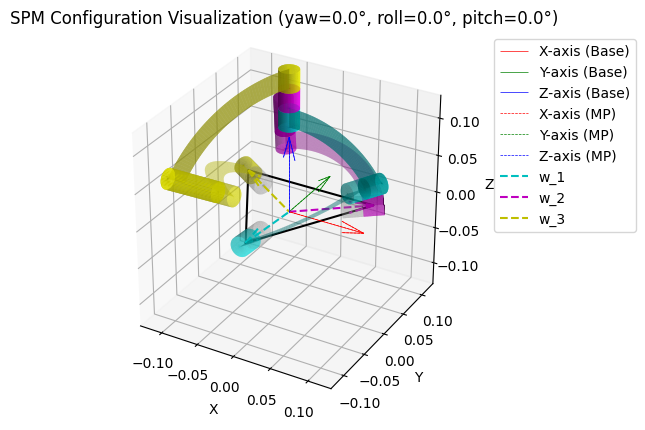


 Desired Rotation Matrix R_des from ZYX euler angles: 30.0, 30.0, 29.999999999999996 (deg)
[[ 0.75       -0.4330127   0.5       ]
 [ 0.64951905  0.625      -0.4330127 ]
 [-0.125       0.64951905  0.75      ]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.4749,  -0.6604,  -0.5817]
norm of w_1 = 1.000000
w_2 = [w_2x, w_2y, w_2z] = [  0.4749,   0.8339,   0.2810]
norm of w_2 = 1.000000
w_3 = [w_3x, w_3y, w_3z] = [ -0.8192,  -0.2868,   0.4967]
norm of w_3 = 1.000000

 Leg 1: A_1 = 0.571890, B_1 = 0.411313
  cos(alpha_1_2) = 0.000000
  w_i·c = -0.290840
  C_1 = cos(alpha_1_2) - w_i·c = 0.290840

 Leg 2: A_2 = 0.717310, B_2 = 0.419792
  cos(alpha_2_2) = 0.000000
  w_i·c = 0.140525
  C_2 = cos(alpha_2_2) - w_i·c = -0.140525

 Leg 3: A_3 = 0.490181, B_3 = 0.569794
  cos(alpha_3_2) = 0.000000
  w_i·c = 0.248366
  C_3 = cos(alpha_3_2) - w_i·c = -0.248366

solving A·cos(θ) + B·sin(θ) = C for leg 1
  A_1 = 0.571890, B_1 = 0.411313, C_1 = 0.290840
Leg 1 solutions for theta

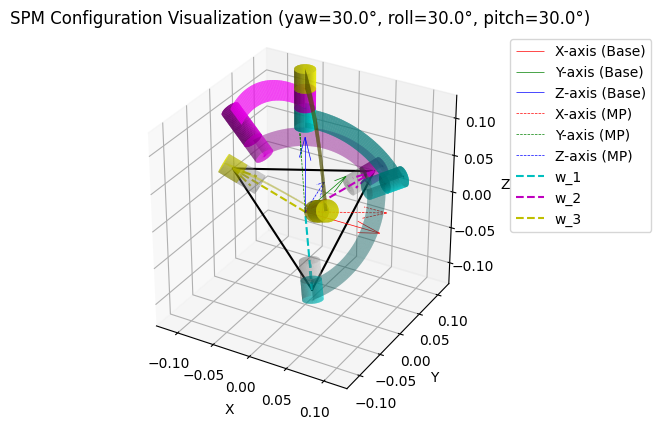

In [96]:

# loop over differnet desired orientations (Yaw-Pitch-Roll)
euler_angles_set = [
    [0, 0, 0],  
    [np.pi/6, np.pi/6, np.pi/6],
    # [np.pi/4, np.pi/3, np.pi/6],
    # [-np.pi/4, 0, 0],
    # [0, np.pi/4, 0],
]

spm = SPM()

for euler_angles in euler_angles_set:
    # print("\n" + "="*60)

    # compute desired rotation matrix
    R_des = R.from_euler('zyx', euler_angles).as_matrix()

    print(f"\n Desired Rotation Matrix R_des from ZYX euler angles: {np.rad2deg(euler_angles[0]):.1f}, {np.rad2deg(euler_angles[1]):.1f}, {np.rad2deg(euler_angles[2])} (deg)")
    print(R_des)
    # print()
    
    sols, has_sols = spm.compute_ik(R_des, verbose=True, update_config=True)
    J, A, B = spm.compute_vel_jacobian()
    print(f"Jacobian J = inv(A)*B: \n {J}")
    print(f"A: \n {A}")
    print(f"B: \n {B}")

    spm.visualize_configuration(R_des)

    # TODO:
    # Workspace check for ankle ROM 


Initialized SPM Mechanism
Absolute Joint Angles (degs) at Neutral Pose (sol indices [0, 0, 0]):
theta_1: 39.7, theta_2: 39.7, theta_3: 39.7
Jacobian at Neutral Pose:
[[-0.82543381  0.33435115  0.49108267]
 [ 0.09048899 -0.76009115  0.66960216]
 [ 0.33333333  0.33333333  0.33333333]]
A matrix at Neutral Pose:
[[-0.44004609  0.04824048  0.55139123]
 [ 0.17824556 -0.40521134  0.55139123]
 [ 0.26180053  0.35697085  0.55139123]]
B matrix at Neutral Pose:
[[0.55139123 0.         0.        ]
 [0.         0.55139123 0.        ]
 [0.         0.         0.55139123]]


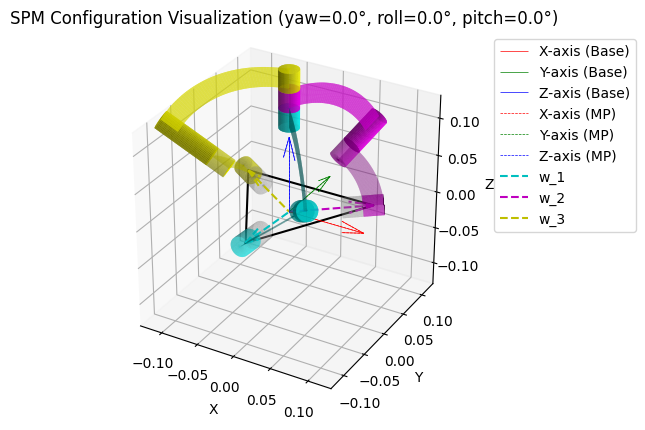

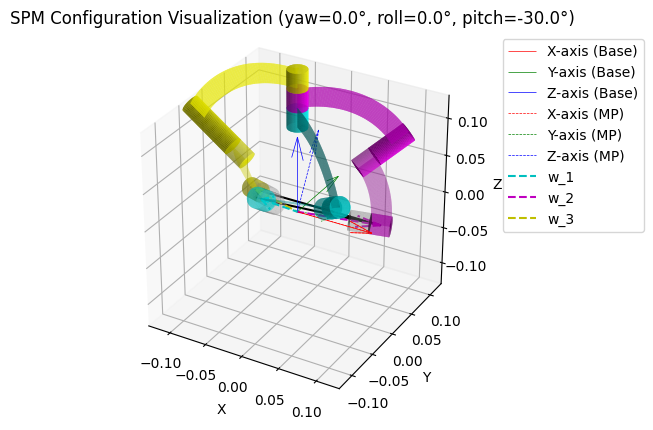

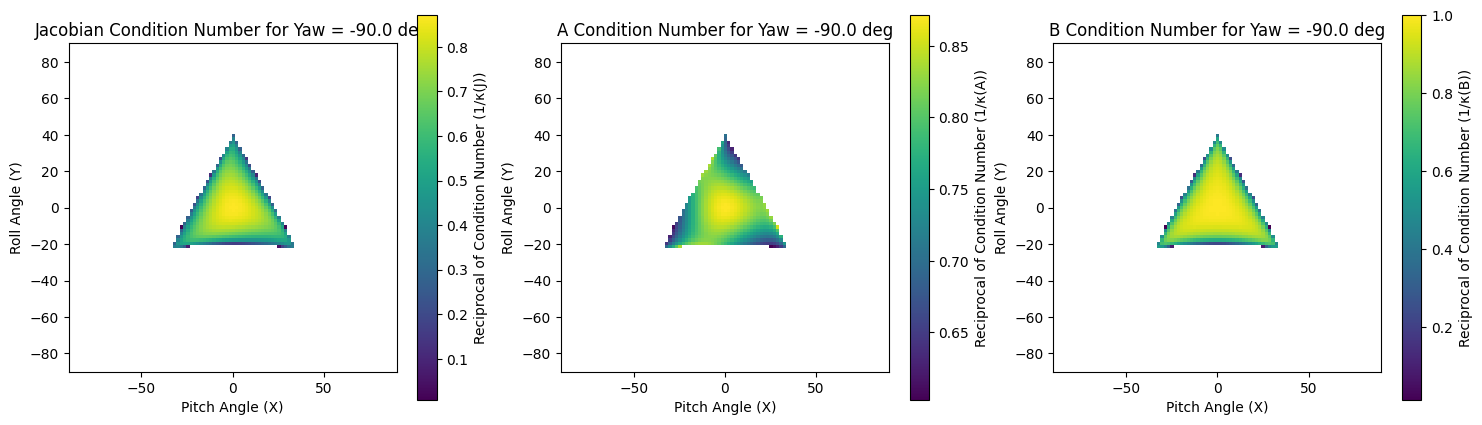

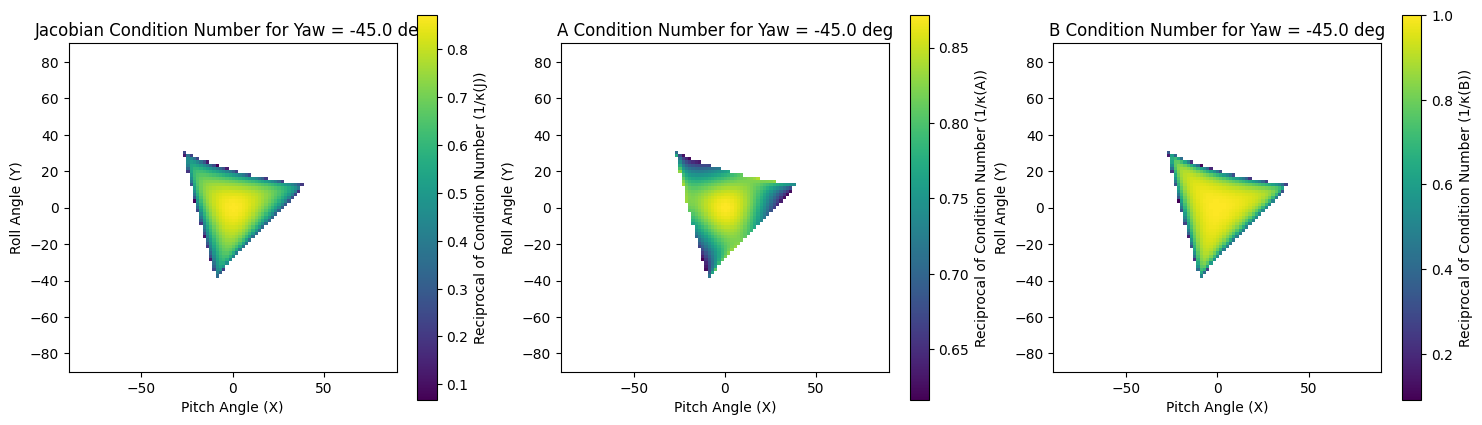

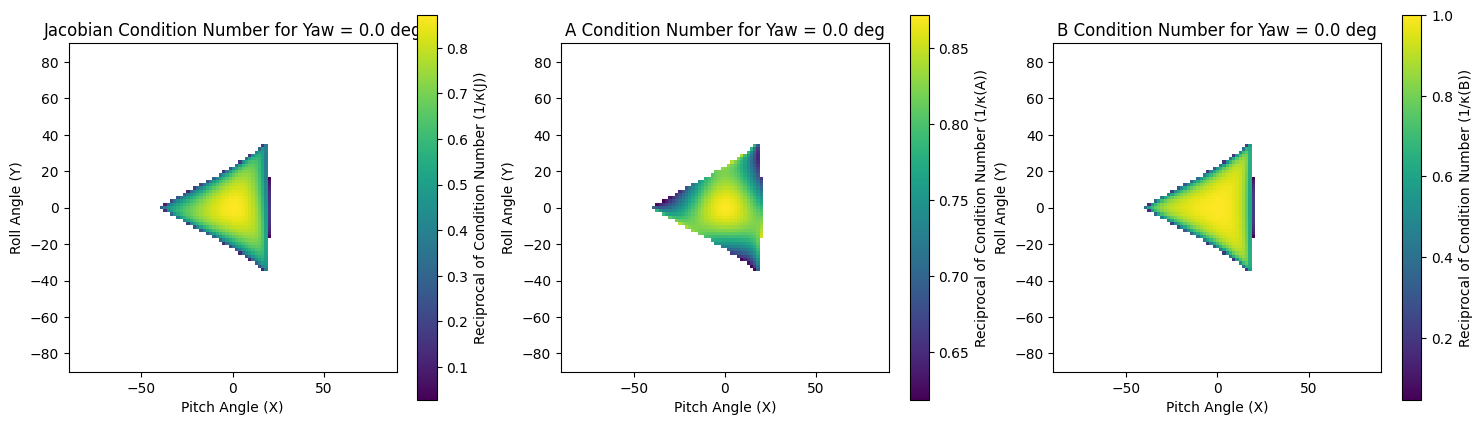

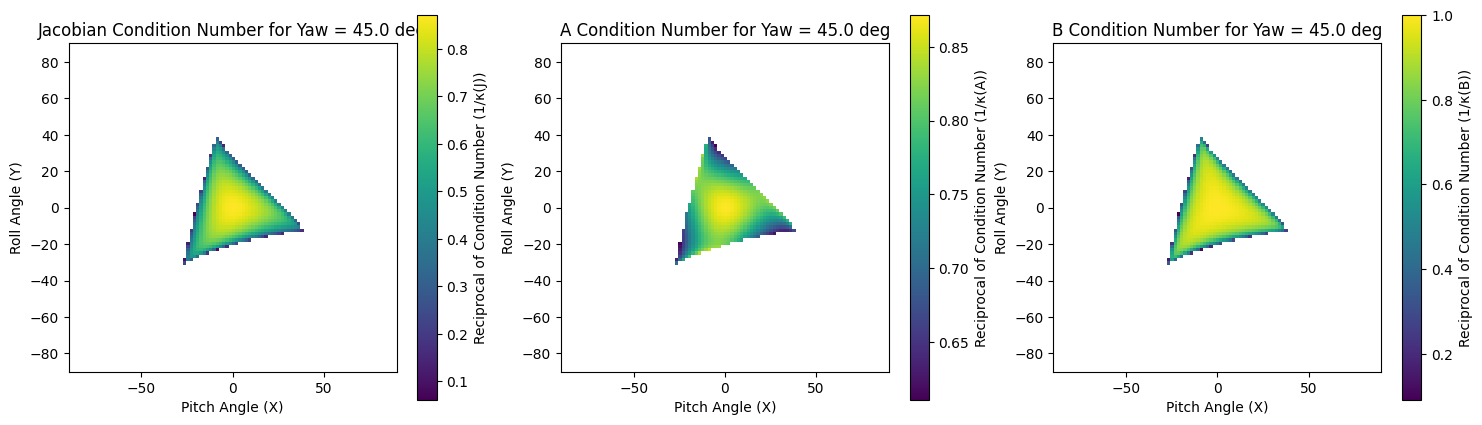

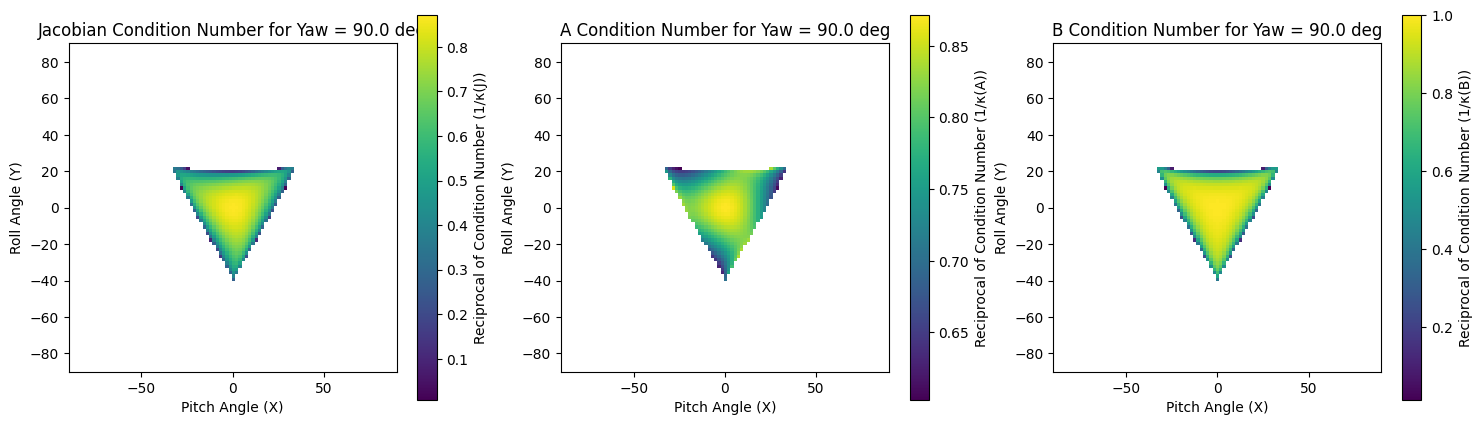

In [97]:
# define euler angle in radian (odd number of points to include zero in the middle)
N_z = 5
N_y = 101 # 51
N_x = N_y # 51

z_yaws = np.linspace(-np.pi/2, np.pi/2, N_z)
y_rolls = np.linspace(-np.pi/2, np.pi/2, N_y)
x_pitches = np.linspace(-np.pi/2, np.pi/2, N_x)

# create meshgrid for plotting
X_pitchesm, Y_rolls, Z_yaws = np.meshgrid(x_pitches, y_rolls, z_yaws, indexing='ij')

Z_jcond = np.zeros_like(Z_yaws)
Z_Acond = np.zeros_like(Z_yaws)
Z_Bcond = np.zeros_like(Z_yaws)

# initialize SPM class object
offset_angle = np.pi/2
# spm = SPM(eta_i2=[0 + offset_angle, np.pi/2 + offset_angle, 3*np.pi/2 + offset_angle])
spm = SPM(eta_i2=[0, 2*np.pi/3, 4*np.pi/3], alpha_i2=[np.pi/4, np.pi/4, np.pi/4]) # ankle SPM

viz_euler_angles = [0, 0, 0] # yaw, roll, pitch for visualization
R_des = R.from_euler('zyx', viz_euler_angles).as_matrix()
spm.visualize_configuration(R_des) 

# viz_euler_angles = [0, np.pi/2 + np.deg2rad(5), -np.pi/4] # yaw, roll, pitch for visualization
viz_euler_angles = [0, 0, -np.pi/6] # yaw, roll, pitch for visualization
R_des = R.from_euler('zyx', viz_euler_angles).as_matrix()
spm.visualize_configuration(R_des) 

for k in range(N_z):

    # fig = plt.figure()
    # axes = fig.add_subplot()

    fig_cond, (ax_jcond, ax_Acond, ax_Bcond) = plt.subplots(1, 3, figsize=(18, 5))

    W_feasible = []

    for j in range(N_y):

        W_feasible_j = []

        for i in range(N_x):

            curr_euler_angles = [z_yaws[k], y_rolls[j], x_pitches[i]]
            R_des = R.from_euler('zyx', curr_euler_angles).as_matrix()
            sols, has_sols = spm.compute_ik(R_des, verbose=False, update_config=True)

            if all(has_sols):
                W_feasible_j.append('b')
                col = 'b'
                mark = 'o'
                # reciprocal of condition number to visualize better (higher is better)
                J, A, B = spm.compute_vel_jacobian()
                Z_jcond[i,j,k] = spm.compute_conditioning_index(J) # Jacobian conditioning index
                Z_Acond[i,j,k] = spm.compute_conditioning_index(A) # A platform singularity check
                Z_Bcond[i,j,k] = spm.compute_conditioning_index(B) # B leg singularity check

            else: 
                # not all legs have solutions; unfeasible workspace
                W_feasible_j.append('k')
                col = 'r'
                mark = '.'
                Z_jcond[i,j,k] = np.nan # assign none condition number for unfeasible points
                Z_Acond[i,j,k] = np.nan
                Z_Bcond[i,j,k] = np.nan

            # axes.plot(np.rad2deg(x_pitches[i]), np.rad2deg(y_rolls[j]), marker=mark, color=col, linestyle='none')
        
        W_feasible.append(W_feasible_j)
    
    # axes.set_aspect('equal')
    # axes.set_title(f'Yaw Angle (Z) = {np.rad2deg(z_yaws[k])} deg')
    # axes.set_xlabel('Pitch Angle (X)')
    # axes.set_ylabel('Roll Angle (Y)')

    # condition number plot
    im = ax_jcond.imshow(Z_jcond[:,:,k].T, extent=(np.rad2deg(x_pitches[0]), np.rad2deg(x_pitches[-1]), np.rad2deg(y_rolls[0]), np.rad2deg(y_rolls[-1])), origin='lower', aspect='equal', cmap='viridis')
    ax_jcond.set_title(f'Jacobian Condition Number for Yaw = {np.rad2deg(z_yaws[k])} deg')
    ax_jcond.set_xlabel('Pitch Angle (X)')
    ax_jcond.set_ylabel('Roll Angle (Y)')
    plt.colorbar(im, ax=ax_jcond, label='Reciprocal of Condition Number (1/κ(J))')

    im = ax_Acond.imshow(Z_Acond[:,:,k].T, extent=(np.rad2deg(x_pitches[0]), np.rad2deg(x_pitches[-1]), np.rad2deg(y_rolls[0]), np.rad2deg(y_rolls[-1])), origin='lower', aspect='equal', cmap='viridis')
    ax_Acond.set_title(f'A Condition Number for Yaw = {np.rad2deg(z_yaws[k])} deg')
    ax_Acond.set_xlabel('Pitch Angle (X)')
    ax_Acond.set_ylabel('Roll Angle (Y)')
    plt.colorbar(im, ax=ax_Acond, label='Reciprocal of Condition Number (1/κ(A))')

    im = ax_Bcond.imshow(Z_Bcond[:,:,k].T, extent=(np.rad2deg(x_pitches[0]), np.rad2deg(x_pitches[-1]), np.rad2deg(y_rolls[0]), np.rad2deg(y_rolls[-1])), origin='lower', aspect='equal', cmap='viridis')
    ax_Bcond.set_title(f'B Condition Number for Yaw = {np.rad2deg(z_yaws[k])} deg')
    ax_Bcond.set_xlabel('Pitch Angle (X)')
    ax_Bcond.set_ylabel('Roll Angle (Y)')
    plt.colorbar(im, ax=ax_Bcond, label='Reciprocal of Condition Number (1/κ(B))')
    plt.show()
 


## 10. TODO: Further Work

- [ ] Implement full FK equation derivation (quadratic/quartic formulation)
- [/] Derive IK closed-form solution
- [ ] Add workspace analysis
- [ ] Generate test cases with known FK solutions
- [ ] Compare Class I, II, III architectures
- [ ] Add singularity analysis
- [ ] Add all other references